                                               # HR EMPLOYEE ATTRITION ANALYSIS 

# THE OBJECTIVE OF MY PROJECT :
The aim of this project is to predict employee attrition using exploratory data analysis and  machine learning which  identify the major factors
responsible for employees leaving the organization.

In [25]:
import pandas as pd               #  data handling (DataFrame)
import numpy as np                 # numerical operations
import matplotlib.pyplot as plt    # this two libraries r for visvalization so whatever the charts we will make we  will use matplotlib and seaborn
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')      #  warning we r importing bcz whenever we r doing coding sometimes a red line showing so in order to ignore that red line we r importing warning 
%matplotlib inline                       


In [26]:
pwd

'D:\\JUPYTER PROJECTS'

                                             # LOAD DATASET 

In [27]:
data=pd.read_csv("D:\Data Anyaletics/HR-Employee-Attrition.csv")

In [28]:
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


                                                            # STARTS BASIC DATA INSPPECTION 

In [29]:
data.head()      # it will show starting 4 details of dataset which usually help us to understand which type of data we have 

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# data.shape function shows the total number of rows and columns present in the dataset ,so we have 1470-rows and 35 columns

In [30]:
data.shape         

(1470, 35)

In [31]:
data.columns

Index(['        Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

 data.columns functions shows all the column names of the dataset

In [32]:
data.columns = data.columns.str.strip()
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

 # Observation : in the eariler step their was the extra space seen in the column name =AGE ,
 SO for removal of that space from this particular column i used the str.strip()

In [33]:
data.size        # It shows the size of the whole dataset 

51450

In [34]:
data.info()  #data.info function helps to understand the data types ,null values and memory usage .so dtypes are int and object ,
#their is no null values means  it  indicates that the dataset is clean and does not require imputation techniques like mean, median, or mode filling.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [35]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# OBSERVATIONS : data.describe() is used to generate descriptive statistics for all numerical columns in the dataset. It provides a summary of the data including count, mean, standard deviation, minimum value, quartiles (25%, 50%, 75%), and maximum value. This helps understand the distribution of data, identify unusual values, and analyze overall patterns before preprocessing and model building.

# Insights from the HR Attrition dataset:
# The dataset contains 1470 employee records, as shown by the count value for all variables.
#  average age of employees is approximately 37 years, with the youngest employee being 18 years and the oldest 60 years.
# Employees live at an average distance of around 9 km from home, while the maximum distance is 29 km.
# The average total working experience is approximately 11 years, with some employees having 40 years of experience.
# The average employee tenure in the company is around 7 years, while some employees stayed for up to 40 years.
# The mean value of WorkLifeBalance is approximately 2.76, indicating moderate work-life balance among employees.
# The YearsSinceLastPromotion average is around 2 years, but some employees have gone 15 years without promotion.
# The StandardHours column has a constant value (80) with zero standard deviation, indicating no variation and potentially no predictive importance.
# EmployeeCount is always 1, meaning it is a constant feature and may not contribute to prediction models.

In [36]:
data.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

# OBSERVATIONS : 
data.dtypes is used to display the data type of each column in the dataset. It helps identify whether a variable 
is numerical (int64) or categorical (object).

In [37]:
data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# OBSERVATIONS :
I checked for missing values using data.isnull().sum(), and found that there are no missing values in any column. This means the dataset is clean and does not require any imputation techniques like mean, median, or mode filling. Having no missing values helps ensure better model performance and simplifies preprocessing.

In [38]:
data.duplicated().sum()

np.int64(0)

# OBSERVATIONS: 
I checked for duplicate records using data.duplicated().sum(), and the result was 0, which means there are no duplicate rows in the dataset. This ensures data quality and prevents bias in analysis or model training. Duplicate records can distort analysis and lead to incorrect model predictions, so it's important to remove them if present.

In [39]:
data.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

# OBSERVATIONS:
data.nunique() is used to calculate the total number of unique values present in each column of the dataset. It helps understand the 
variability of features, identify categorical variables and detect constant columns that may not contribute to machine learning models.
    
Age has 43 unique values, indicating employees belong to different age groups.
Attrition has 2 unique values, representing employees who stayed or left the company (Yes/No).
BusinessTravel contains 3 categories, showing different travel frequencies.
Department has 3 unique departments within the organization.
JobRole contains 9 unique job positions.
Gender has 2 categories, representing male and female employees.
MaritalStatus has 3 categories, such as single, married, and divorced.
MonthlyIncome has 1349 unique values, indicating high variation in employee salaries.
EmployeeNumber has 1470 unique values, meaning each employee has a unique ID and this feature may not be useful for prediction.
EmployeeCount, Over18, and StandardHours each have only 1 unique value, indicating constant columns with no variability and potentially low predictive importance.
TotalWorkingYears has 40 unique values, showing variation in employee experience levels.
YearsAtCompany has 37 unique values, indicating different employee tenures.
    

In [40]:
#now we will segregate the data categorical 
cat_col = [fea for fea in data.columns if data[fea].dtypes =='object']
cat_col

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

# observations : This code is used to extract all categorical columns from the dataset. It checks each column’s data type and selects columns with object datatype, which usually contain text or category values.
Categorical variables cannot be directly used in most machine learning algorithms. Therefore, identifying them is necessary before applying encoding techniques such as:

Label Encoding
One-Hot Encoding
Insights from the HR Attrition dataset:

The dataset contains 9 categorical columns, which need preprocessing before training machine learning models like Logistic Regression or Random Forest.

Some categorical features, such as OverTime, JobRole, and BusinessTravel, may strongly influence employee attrition.

In [41]:
num_col = [fea for fea in data.columns if data[fea].dtypes !='object']
num_col 

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

# Observations : This code is used to extract all numerical columns from the dataset. It checks each column’s data type and selects columns that are not of type object, meaning they contain numerical values such as integers or continuous variables.

Identifying numerical columns helps in:

Performing statistical analysis (mean, median, std)
Creating histograms, boxplots, correlation analysis
Detecting outliers
Applying feature scaling (StandardScaler, MinMaxScaler)
Training machine learning models

The dataset contains 26 numerical variables, which represent employee characteristics such as experience, salary, satisfaction, working years, and performance metrics.

In [42]:
cat_data = data[cat_col] # here dataframe of object type catagorical data 
cat_data

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,Y,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Y,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,Y,No


In [43]:
numeric_data = data[num_col]
numeric_data               # This code is used to extract all numerical columns from the original dataset and create a new DataFrame called
        #numeric_data. The new DataFrame contains only numerical features such as employee age, income, experience, and working years.

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,...,1,80,0,8,0,1,6,4,0,5
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0,7,3,3,0,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0,8,3,3,8,7,3,0
4,27,591,2,1,1,7,1,40,3,1,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,1,2061,3,41,4,2,...,3,80,1,17,3,3,5,2,0,3
1466,39,613,6,1,1,2062,4,42,2,3,...,1,80,1,9,5,3,7,7,1,7
1467,27,155,4,3,1,2064,2,87,4,2,...,2,80,1,6,0,3,6,2,0,3
1468,49,1023,2,3,1,2065,4,63,2,2,...,4,80,0,17,3,2,9,6,0,8


In [44]:
cat_data=cat_data.drop("Over18",axis=1)  # This code is used to remove the Over18 column from the categorical DataFrame because the column contains 
                                            #only one unique value and does not provide useful information for analysis or prediction.
cat_data

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,No
...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,No


In [45]:
numeric_data=numeric_data.drop(["EmployeeCount","EmployeeNumber","StandardHours"],axis=1)
numeric_data                  #  This code is used to remove unnecessary numerical columns from the dataset because these features have constant 
                               #   values or act as unique identifiers, which do not contribute to predicting employee attrition.

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,2,94,3,2,4,5993,...,3,1,0,8,0,1,6,4,0,5
1,49,279,8,1,3,61,2,2,2,5130,...,4,4,1,10,3,3,10,7,1,7
2,37,1373,2,2,4,92,2,1,3,2090,...,3,2,0,7,3,3,0,0,0,0
3,33,1392,3,4,4,56,3,1,3,2909,...,3,3,0,8,3,3,8,7,3,0
4,27,591,2,1,1,40,3,1,2,3468,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,2,4,2571,...,3,3,1,17,3,3,5,2,0,3
1466,39,613,6,1,4,42,2,3,1,9991,...,3,1,1,9,5,3,7,7,1,7
1467,27,155,4,3,2,87,4,2,2,6142,...,4,2,1,6,0,3,6,2,0,3
1468,49,1023,2,3,4,63,2,2,2,5390,...,3,4,0,17,3,2,9,6,0,8


 #                                                        EXPLORATORY DATA ANALYSIS STARTS

 # Step 1: Attrition distribution check

In [46]:
data["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

# OBSERVATIONS : This function counts the frequency of each unique value in the Attrition column.

Your Attrition column contains:

Yes → Employee left the company
No → Employee stayed in the company

You can write this explanation in your notebook:

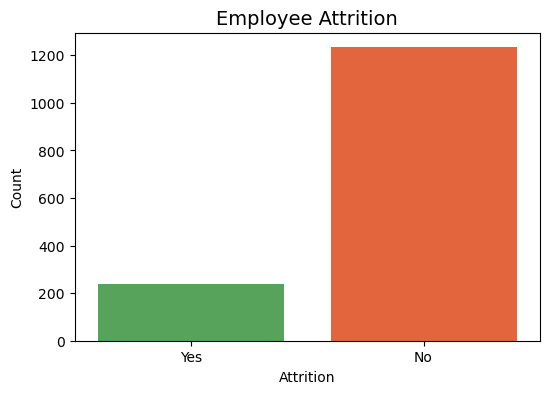

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x="Attrition",
    data=data,
    palette=["#4CAF50", "#FF5722"]
)

plt.title("Employee Attrition", fontsize=14)
plt.xlabel("Attrition")
plt.ylabel("Count")

plt.show()

# OBSERVATIONS :The count plot helps analyze the distribution of employee attrition.
This indicates:
No     1233
Yes     237
Most employees stayed in the company.
Fewer employees left the company.
The dataset is imbalanced, that means  the target variable contains unequal class distribution.


This visualization helps:

Understand employee retention patterns
Detect target variable imbalance
Identify potential preprocessing requirements
Support business insights regarding employee turnover

# Step 2: Numerical columns histogram

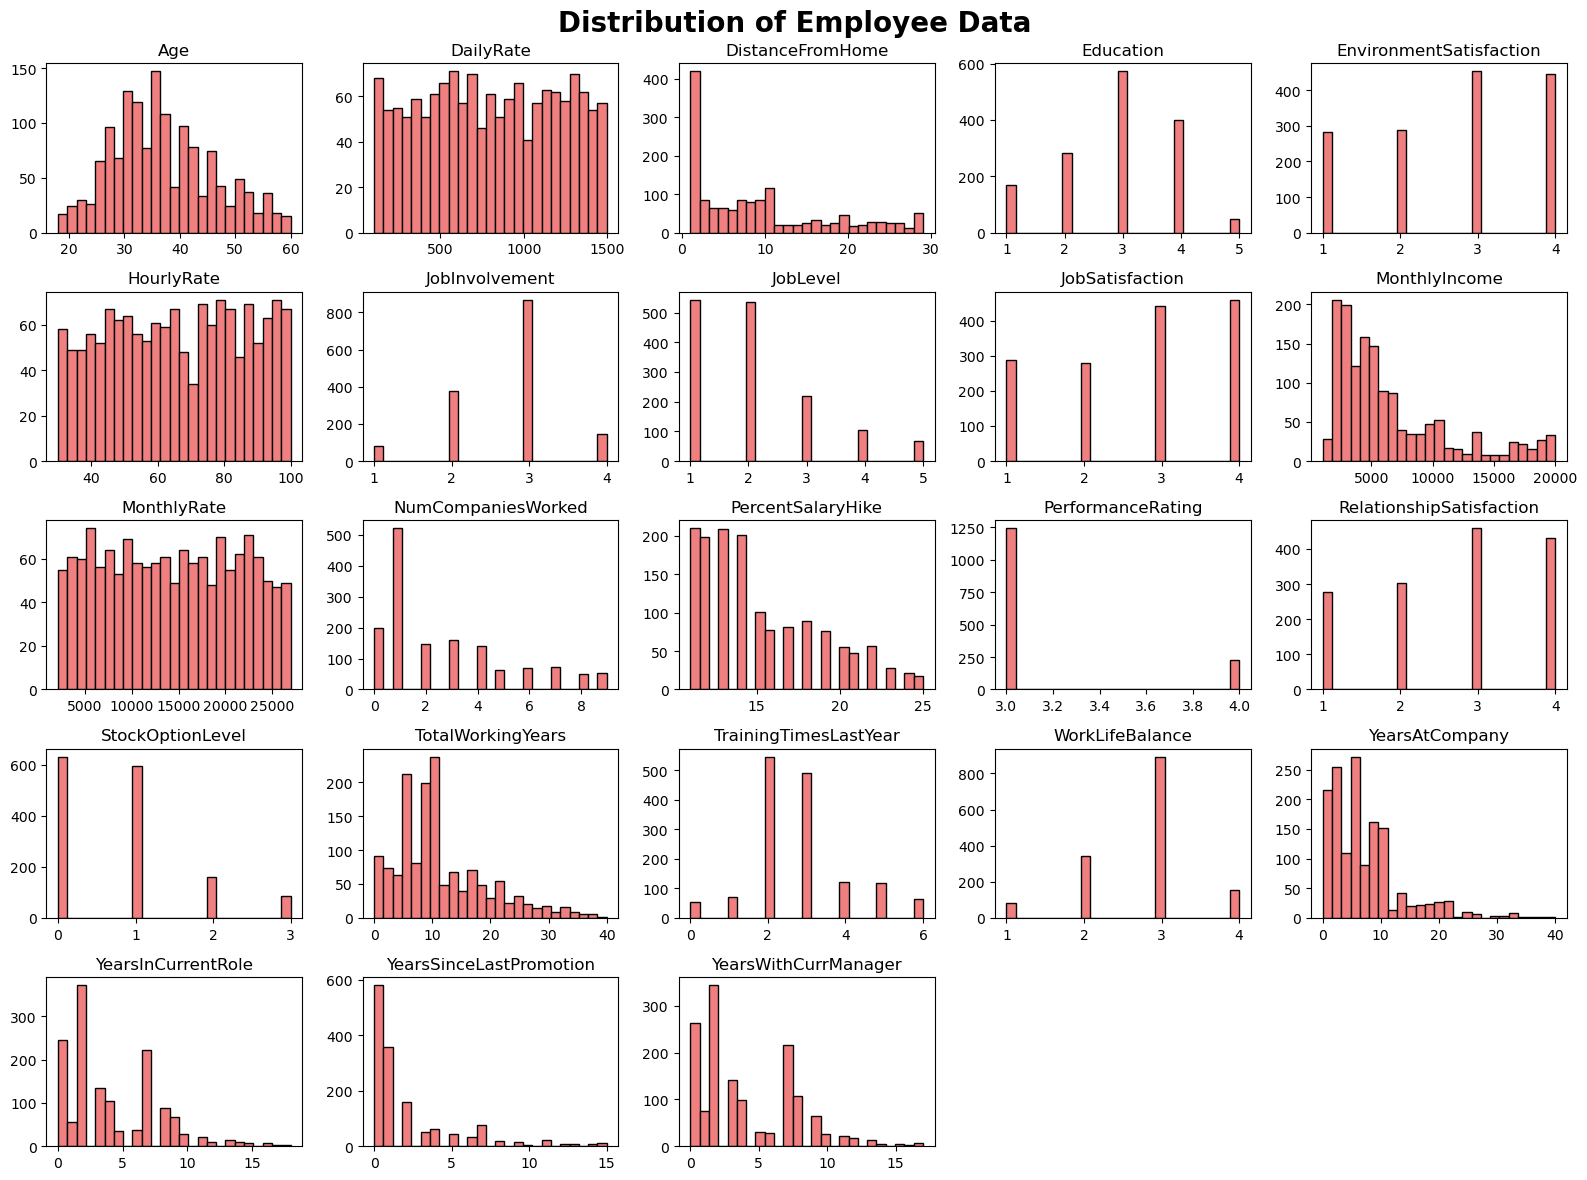

In [48]:
import matplotlib.pyplot as plt

numeric_data.hist(
    figsize=(16,12),
    bins=25,
    color='lightcoral',
    edgecolor='black',
    grid=False
)

plt.suptitle(
    "Distribution of Employee Data",
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# observations:  Histograms were used to visualize the distribution of all numerical variables in the HR Attrition dataset. This helped identify patterns, skewness, variability, and potential outliers before applying preprocessing and machine learning models.

Insights from HR Attrition dataset:

By observing histograms, we can analyze distributions of variables such as:

Age → Employee age distribution
MonthlyIncome → Salary distribution
TotalWorkingYears → Experience distribution
YearsAtCompany → Employee tenure
DistanceFromHome → Distance variation

# Step 3: Categorical columns analysis

In [49]:
pd.crosstab(data["Department"], data["Attrition"])

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


# OBSERVATIONS:This code is used to create a cross-tabulation (contingency table) between the Department and Attrition columns. It helps analyze how employee attrition varies across different departments.

Human Resources:
51 employees stayed
12 employees left

Attrition exists but the department has fewer employees overall.

Research & Development:
828 employees stayed
133 employees left

This department has the largest workforce and also the highest number of attrition cases.

Sales:
354 employees stayed
92 employees left


Sales shows comparatively higher employee turnover, indicating attrition may be more common in this department.

The cross-tabulation suggests:

Most employees belong to Research & Development.
Sales department appears to experience relatively higher attrition.
Attrition patterns differ among departments.

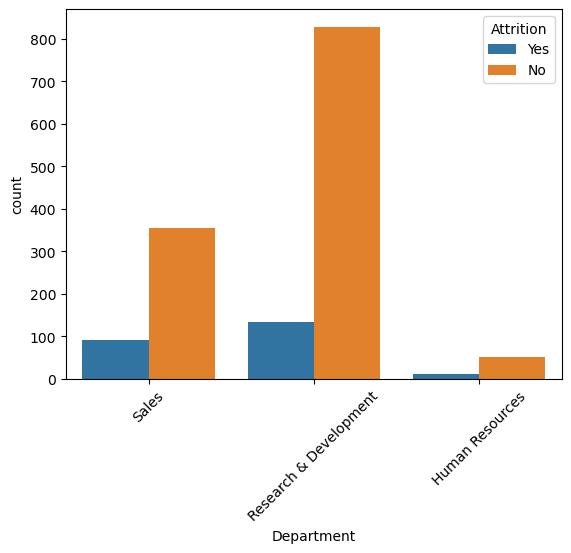

In [50]:
sns.countplot(x="Department",
              hue="Attrition",
              data=data)
plt.xticks(rotation=45)
plt.show()

# OBSERVATIONS :This creates a count plot (bar chart) showing the number of employees in each department, separated by attrition status.
From the visualization:

Human Resources:
Lower total employees
Lower attrition count
Research & Development:
Largest number of employees
Highest number of employees retained
Highest total attrition count due to larger workforce
Sales:
Comparatively fewer employees than R&D
Higher attrition proportion

This suggests Sales department experiences relatively greater employee turnover.

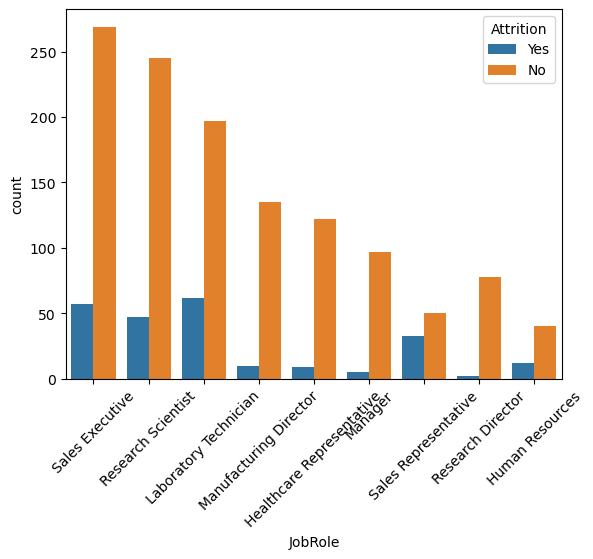

In [51]:
sns.countplot(x="JobRole",
              hue="Attrition",
              data=data)
plt.xticks(rotation=45)
plt.show()

# observations : This code creates a count plot to visualize the relationship between employee Job Role and Attrition status.
 # The graph helps compare the number of employees who stayed and left the company for each job role.

 Important insight:
If Sales Executive or Laboratory Technician shows a larger Yes bar in your graph, those roles may have higher attrition risk and could become important predictors in your machine learning model.

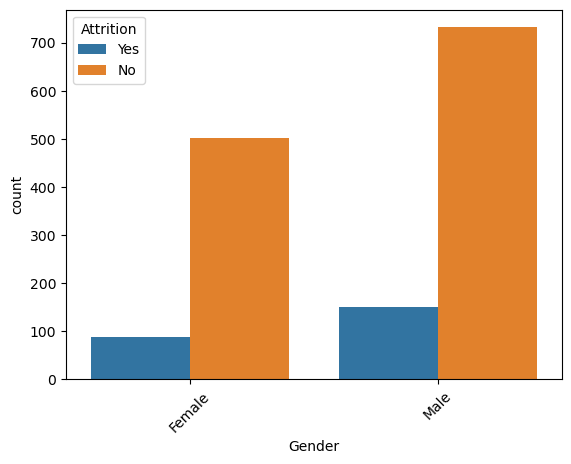

In [52]:
sns.countplot(x="Gender",
              hue="Attrition",
              data=data)
plt.xticks(rotation=45)
plt.show()

# observations : This code creates a count plot (bar chart) to compare employee attrition across different genders.

The analysis shows that male employees have higher attrition counts than female employees, but this may be influenced by the larger male workforce. Overall, most employees from both genders remained in the company, indicating that employee retention is higher than attrition regardless of gender

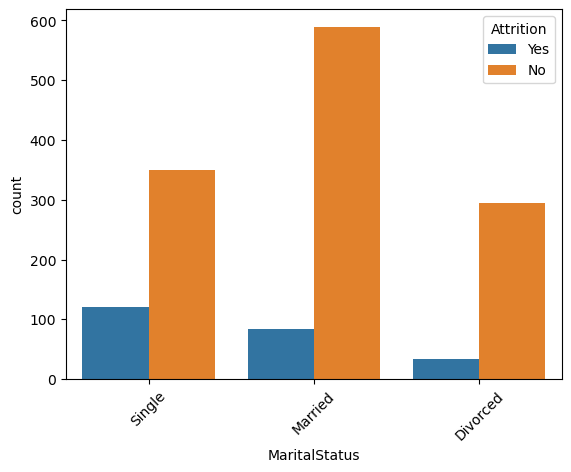

In [53]:
sns.countplot(x="MaritalStatus",
              hue="Attrition",
              data=data)
plt.xticks(rotation=45)
plt.show()

# observations :
Insights from Marital Status vs Attrition Plot:
1. Married employees have the highest retention (No), indicating most married employees continue working in the company.
2.Single employees show higher attrition (Yes) compared to married and divorced employees, suggesting single employees are more likely to leave the        organization.
3. Divorced employees have the lowest attrition count, meaning employee turnover appears lower in this group.
   Although married employees have more attrition cases in count than divorced employees, this is likely because the total number of married employees     is much higher.
     The proportion of employees leaving appears highest among single employees, indicating marital status may influence employee retention behavior.
   Interpretation:
Single employees may have greater career mobility, job switching tendency, or fewer personal constraints, which can contribute to higher attrition.
Married employees appear more stable in terms of employment retention.
Divorced employees show comparatively lower turnover.

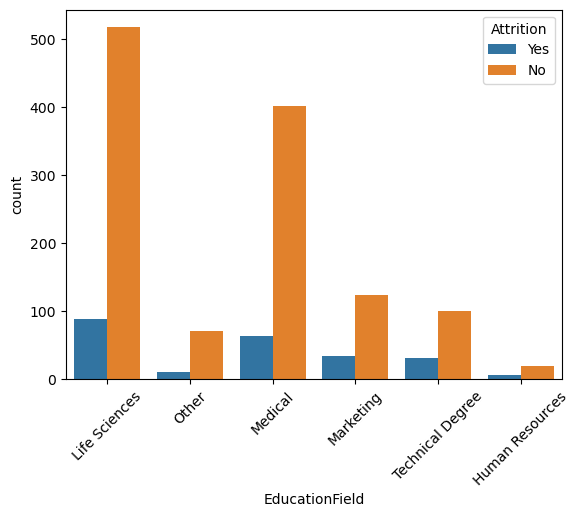

In [54]:
sns.countplot(x="EducationField",
              hue="Attrition",
              data=data)
plt.xticks(rotation=45)
plt.show()

# observations:

Insights from Education Field vs Attrition Plot:
1. Employees from Life Sciences have the highest workforce size and also show the highest number of attrition cases in absolute count.
2. Medical field employees also have a large workforce, with noticeable attrition, but lower than Life Sciences.
3. Marketing and Technical Degree employees show moderate attrition levels, indicating some employee turnover in these fields.
4. Human Resources and Other education fields have the lowest attrition counts, likely due to fewer employees in these categories.
   For all education fields, the number of employees who stayed (No) is much higher than employees who left (Yes), indicating overall retention is        greater than attrition.
Although Life Sciences has the highest attrition count, this may be influenced by having the largest employee population, so attrition percentage would provide a more accurate comparison.
Interpretation:
1.Employees from Life Sciences and Medical backgrounds form a major portion of the workforce.
2.Education field may influence attrition patterns, but workforce size should be considered before drawing conclusions.
3. Fields with higher attrition may require further investigation regarding workload, career growth, or job satisfaction.

Step 4: Correlation heatmap

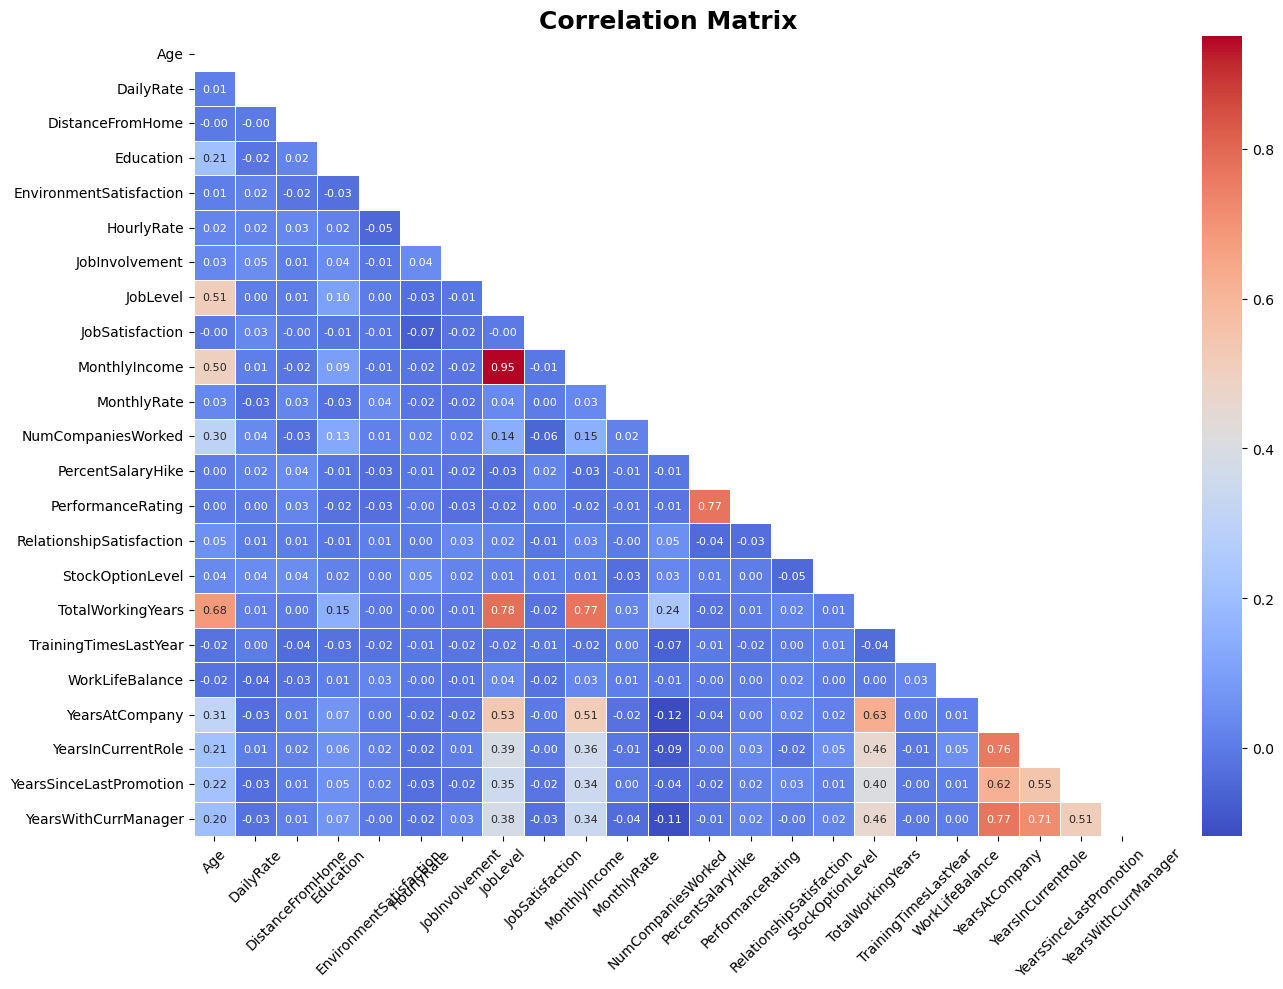

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr = numeric_data.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size":8}
)

plt.title(
    "Correlation Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# observations:
+1 → Strong positive correlation
0 → No correlation
-1 → Strong negative correlation

conculsion:
The correlation matrix was used to identify relationships between numerical variables. Strong positive correlations were observed between JobLevel and MonthlyIncome, TotalWorkingYears and MonthlyIncome, and YearsAtCompany with managerial experience variables, indicating that experience and seniority strongly influence salary and position within the organizat

Step 5: Attrition vs MonthlyIncome

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=data,
    palette=["#4CAF50", "#FF6B6B"],   # custom colors
    linewidth=2
)

plt.title(
    "Monthly Income vs Attrition",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Attrition", fontsize=12)
plt.ylabel("Monthly Income", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# observations 
If employees with Attrition = Yes have lower median income:

Insight:

Employees who left the company generally have lower monthly income compared to employees who stayed. This suggests salary may influence employee retention and lower-paid employees may be more likely to leave.

Also:

The presence of outliers indicates some employees earn significantly higher salaries than others.

And:

Employees with higher monthly income appear to show greater retention, suggesting compensation may contribute to reduced attrition.

Step 6: Attrition vs Age

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="Age",
    data=data,
    palette=["#36A2EB", "#FF6384"],   # blue & pink
    width=0.5,
    linewidth=2
)

plt.title(
    "Age Distribution by Attrition",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Attrition", fontsize=12)
plt.ylabel("Age", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# observations :
Younger employees tend to leave the company more frequently compared to older employees.


Step 7: Attrition vs Overtime

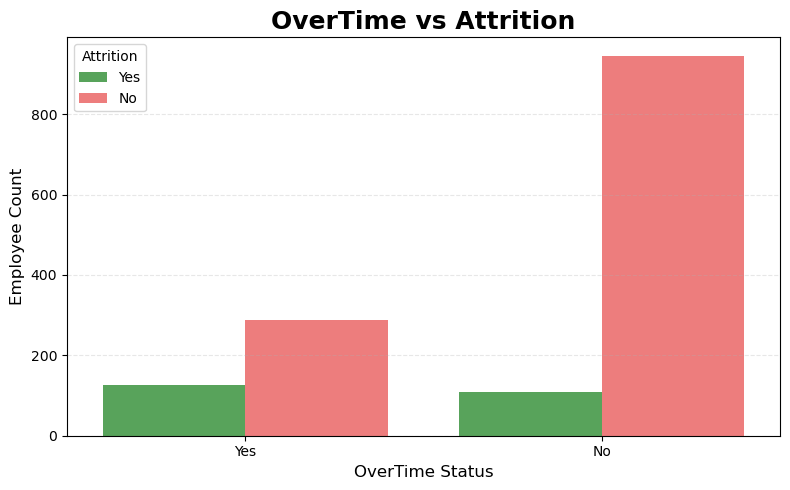

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x="OverTime",
    hue="Attrition",
    data=data,
    palette=["#4CAF50", "#FF6B6B"]   # green & red
)

plt.title(
    "OverTime vs Attrition",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("OverTime Status", fontsize=12)
plt.ylabel("Employee Count", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.legend(title="Attrition")

plt.tight_layout()
plt.show()

# OBSERVATIONS:
Employees with OverTime = Yes have higher Attrition = Yes

Then:

Insight:

Employees working overtime appear more likely to leave the company compared to employees who do not work overtime. This suggests overtime may be an important factor contributing to employee attrition.

FEATURE ENGINNERING 

In [37]:
data["AgeGroup"] = pd.cut(                
    data["Age"],
    bins=[18,25,35,45,55,65],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56+"
    ],
    include_lowest=True
)

data[["Age","AgeGroup"]].head()

,Age,AgeGroup
0,41,36-45
1,49,46-55
2,37,36-45
3,33,26-35
4,27,26-35


# observations: 
This code is used for Feature Engineering, where a continuous numerical variable (Age) is converted into categorical groups (AgeGroup).

Why create Age Groups?

Grouping age helps:

1. Simplify analysis
2. Compare attrition across age categories
3.Detect trends among younger or older employees
4. Improve business interpretation

Employee ages were grouped into different categories using pd.cut() to simplify analysis and identify attrition patterns across age groups. This feature engineering step converts continuous age values into meaningful categorical intervals.


In [38]:
print(data["Age"].min())     # 18 is the minimum age and 60 is the maximum age of the employees
print(data["Age"].max())

18
60


In [39]:
data["AgeGroup"].value_counts()

AgeGroup
26-35    606
36-45    468
46-55    226
18-25    123
56+       47
Name: count, dtype: int64

# observations :
Insights:

1. The majority of employees are between 26 and 35 years old, indicating that the organization has a relatively young workforce.
2. Employees aged 36–45 also represent a significant portion of the workforce, suggesting many mid-career professionals.
3. Older employees form a small proportion of the workforce.(+56)
4. Entry-level or early-career employees represent a smaller portion of the workforce (18-25).

# Create Income Level Feature

In [40]:
data["IncomeLevel"]=pd.qcut(
data["MonthlyIncome"],
q=4,
labels=[
"Low",
"Medium",
"High",
"Very High"
]
)

# observations:
Why create Income Levels?

This helps:

1. Simplify salary analysis.
2. Compare attrition among income groups.
3. Identify whether low-income employees leave more frequently.
4. Improve business interpretation.


In [41]:
data["IncomeLevel"].value_counts()

IncomeLevel
Low          369
Very High    368
High         367
Medium       366
Name: count, dtype: int64

# observations :
Insights from the output:
1. Employees are equally distributed across income levels

Insight:

The income categories contain nearly equal numbers of employees because quantile binning (qcut) divides the data into groups with similar observation counts.

2. No income category dominates the workforce

Insight:

The workforce appears balanced across different salary groups, allowing fair comparison between income levels.

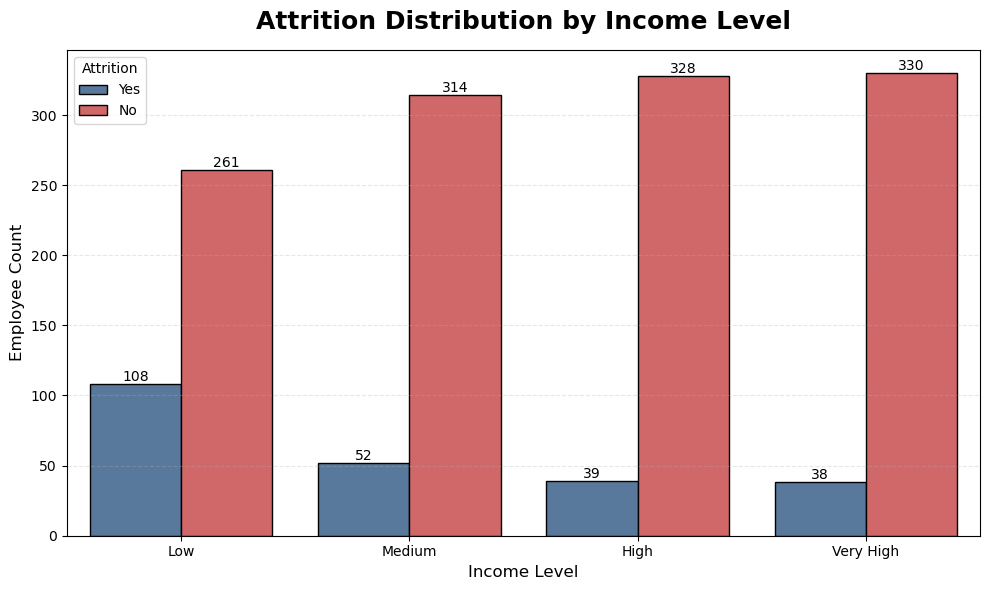

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

ax = sns.countplot(
    x="IncomeLevel",
    hue="Attrition",
    data=data,
    palette=["#4E79A7", "#E15759"],   # blue & red
    edgecolor="black"
)

# Add counts on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=10
    )

plt.title(
    "Attrition Distribution by Income Level",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Income Level",
    fontsize=12
)

plt.ylabel(
    "Employee Count",
    fontsize=12
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.legend(
    title="Attrition",
    frameon=True
)

plt.tight_layout()

plt.show()

# Experience Level Feature

In [43]:
data["ExperienceLevel"]=pd.cut(
data["TotalWorkingYears"],
bins=[0,5,10,20,40],
labels=[
"Beginner",
"Mid",
"Senior",
"Expert"
], 
include_lowest=True
)

# observations:
Why create Experience Levels?

This helps:

1. Simplify employee analysis
2. Compare attrition across experience categories
3. Identify whether beginners or experienced employees leave more frequently
4. Improve business interpretation

In [44]:
data["ExperienceLevel"].value_counts()

ExperienceLevel
Mid         607
Senior      340
Beginner    316
Expert      207
Name: count, dtype: int64

# observations:
Insights from the output:
1. Most employees belong to the Mid experience level
Insight:
The majority of employees have 6–10 years of work experience, indicating that the organization mainly consists of moderately experienced professionals.
2. Senior employees form the second largest group
Insight:
Employees with 11–20 years of experience represent a significant portion of the workforce, showing the presence of experienced professionals.
3. Beginner employees are comparatively fewer
Insight:
Employees with less than 5 years of experience make up a smaller share of the workforce.
4. Expert employees are the smallest group
Insight:
Highly experienced employees (21–40 years) form the smallest proportion of the workforce, suggesting fewer long-tenure professionals.

This indicates the company mainly employs:

Mid-career professionals
Experienced employees
Skilled workforce with moderate to high experience   

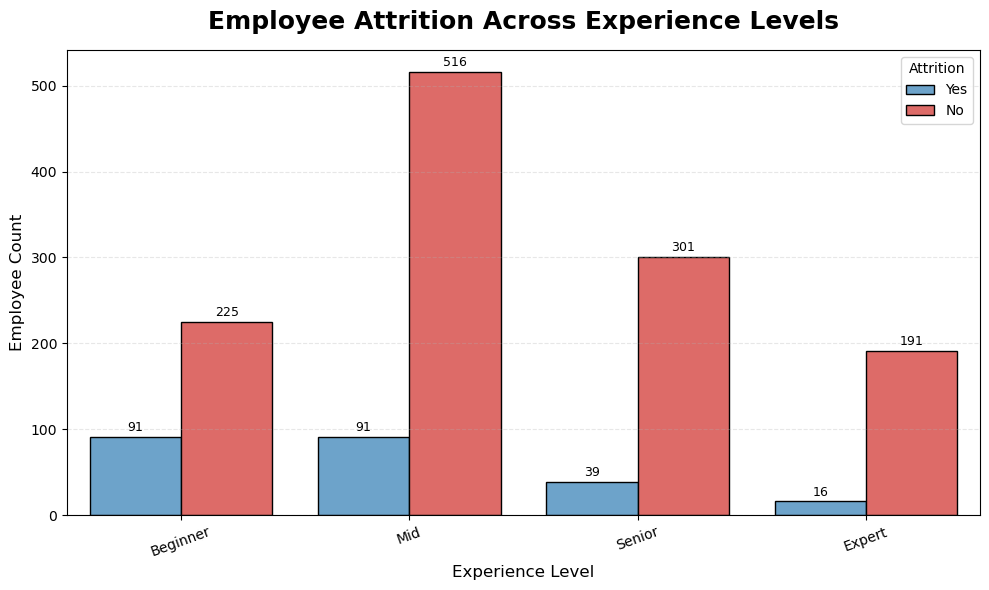

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

ax = sns.countplot(
    x="ExperienceLevel",
    hue="Attrition",
    data=data,
    palette=["#5DA5DA", "#F15854"],   # blue & red
    edgecolor="black"
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=9,
        padding=2
    )

plt.title(
    "Employee Attrition Across Experience Levels",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Experience Level",
    fontsize=12
)

plt.ylabel(
    "Employee Count",
    fontsize=12
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.legend(
    title="Attrition",
    frameon=True
)

plt.xticks(rotation=20)   # if labels overlap

plt.tight_layout()

plt.show()

# Step 4: Overtime Binary Feature

Convert Yes/No → 1/0

In [46]:
data["OverTimeBinary"]=data["OverTime"].map(
{
"Yes":1,
"No":0
}
)

# OBSERVATIONS:
This code is used for encoding categorical data into numerical values, specifically binary encoding.
Conclusion:

The map() function was used to convert the categorical OverTime variable into binary numerical values (Yes = 1, No = 0). This encoding step prepares the feature for machine learning models and further analysis.

In [47]:
data[
["OverTime",
"OverTimeBinary"]
].head()

,OverTime,OverTimeBinary
0,Yes,1
1,No,0
2,Yes,1
3,Yes,1
4,No,0


# OBSERVATIONS:
This code displays the first five rows of both:
Original categorical variable (OverTime)
Encoded numerical variable (OverTimeBinary)

Insight:
Employees working overtime are represented by 1, while employees not working overtime are represented by 0. Converting categorical values into numerical form prepares the feature for machine learning models and statistical analysis.

# Satisfaction Score Feature 

In [48]:
data["OverallSatisfaction"]=(
data["EnvironmentSatisfaction"]
+
data["JobSatisfaction"]
+
data["RelationshipSatisfaction"]
)/3

# OBSERVATIONS:
This code creates a new feature called OverallSatisfaction by calculating the average satisfaction score of employees.
Why create Overall Satisfaction?
This helps:
1.Combine multiple satisfaction metrics into one score
2.Simplify analysis
3.Understand overall employee happiness
4.Compare satisfaction with attrition


In [49]:
data["OverallSatisfaction"].head()

0    2.333333
1    3.000000
2    3.000000
3    3.333333
4    2.333333
Name: OverallSatisfaction, dtype: float64

# OBSERVATIONS :
Insight:

Employees with higher OverallSatisfaction values are generally expected to have better workplace satisfaction, while lower scores may indicate dissatisfaction and potential risk of attrition.


 # Promotion Gap Feature



In [50]:
data["PromotionGap"]=(
data["TotalWorkingYears"]
-
data["YearsSinceLastPromotion"]
)

# OBSERVATIONS:
This code creates a new feature called PromotionGap by subtracting years since last promotion from total working years.

This is a Feature Engineering step.

Why create PromotionGap?
This helps analyze:
1.Career progression
2.Promotion patterns
3.Employee growth opportunities
4.Relationship between promotions and attrition


In [51]:
data["PromotionGap"].head()

0    8
1    9
2    7
3    5
4    4
Name: PromotionGap, dtype: int64

# OBSERVATIONS: 
Insight:
Higher PromotionGap values may indicate:
More work experience
Longer career progression history

Lower values may indicate:
More recent promotions
Faster growth relative to experience

Step 7: Employee Risk Score

In [52]:
data["RiskScore"]=(
(data["OverTimeBinary"]*2)
+
(5-data["JobSatisfaction"])
+
(5-data["EnvironmentSatisfaction"])
)

# OBSERVATIONS : 
This code creates a new feature called RiskScore, which estimates an employee’s potential attrition risk using overtime and satisfaction levels.
Why create RiskScore?
This helps:
1. Identify employees with potential attrition risk
2. Combine multiple factors into one metric
3. Simplify HR analysis
4. Support retention strategies    

In [53]:
data["RiskScore"].describe()

count    1470.000000
mean        5.115646
std         1.737807
min         2.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: RiskScore, dtype: float64

# OBSERVATIONS:
This output gives statistical summary of the newly created RiskScore feature.
The average employee risk score is approximately 5.1, indicating moderate attrition risk overall. Some employees have very high risk scores (up to 10), suggesting possible dissatisfaction or overtime-related burnout.

In [54]:
# Then categorize:

data["RiskCategory"]=pd.cut(
data["RiskScore"],
bins=[0,4,7,10],
labels=[
"Low",
"Medium",
"High"
]
)



# OBSERVATIONS:
This code converts the numerical RiskScore into risk categories. This is another Feature Engineering step.
Why create Risk Categories?
This helps:
1. Simplify analysis
2. Identify high-risk employees quickly
3. Support HR retention strategies
4. Improve interpretation


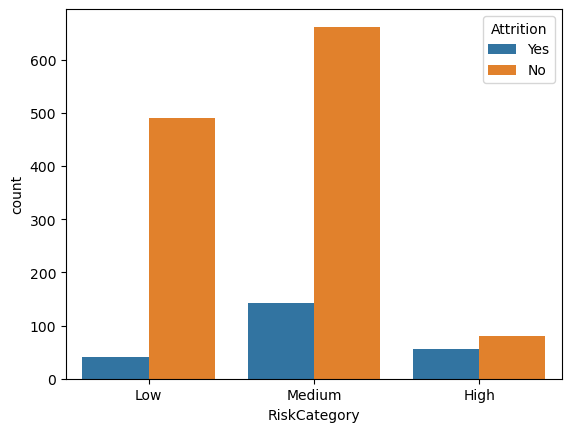

In [55]:
sns.countplot(
x="RiskCategory",
hue="Attrition",
data=data
)

plt.show()

## ML Preprocessing
### Step 1: Define X and y

In [56]:
# Target variable extract
y = data["Attrition"]


X = data.drop(columns=["Attrition"])

print("X shape:", X.shape)
print("y value counts:\n", y.value_counts())

X shape: (1470, 42)
y value counts:
 Attrition
No     1233
Yes     237
Name: count, dtype: int64


# observations: 
This step is very important in Machine Learning preprocessing, because here you separate:
X → Independent variables (Features/Input)
y → Dependent variable (Target/Output)

The dataset was divided into features (X) and target variable (y) for machine learning. X contains 42 predictor variables, while y contains employee attrition status. The target variable is imbalanced, with most employees belonging to the non-attrition category.


### Step 2: One-Hot Encoding (for categorical columns only)

In [57]:
# Step 1: Category dtype → string (pd.cut/qcut columns)
cat_dtype_cols = X.select_dtypes(include="category").columns.tolist()
X[cat_dtype_cols] = X[cat_dtype_cols].astype(str)

# Step 2: now all object columns encode together 
cat_cols = X.select_dtypes(include="object").columns.tolist()
print("Encoding columns:", cat_cols)
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Step 3: Verify — non numeric is not their
print("X shape after encoding:", X.shape)
print("Any object/category left:", X.select_dtypes(include=["object","category"]).shape[1])
X.head()

Encoding columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime', 'AgeGroup', 'IncomeLevel', 'ExperienceLevel', 'RiskCategory']
X shape after encoding: (1470, 63)
Any object/category left: 0


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,AgeGroup_46-55,AgeGroup_56+,IncomeLevel_Low,IncomeLevel_Medium,IncomeLevel_Very High,ExperienceLevel_Expert,ExperienceLevel_Mid,ExperienceLevel_Senior,RiskCategory_Low,RiskCategory_Medium
0,41,1102,1,2,1,1,2,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,279,8,1,1,2,3,61,2,2,...,True,False,False,False,False,False,True,False,False,True
2,37,1373,2,2,1,4,4,92,2,1,...,False,False,True,False,False,False,True,False,False,True
3,33,1392,3,4,1,5,4,56,3,1,...,False,False,True,False,False,False,True,False,False,True
4,27,591,2,1,1,7,1,40,3,1,...,False,False,False,True,False,False,True,False,False,True


# observations :
Why is this important?
Model compatibility
Better preprocessing
 Accurate training

Categorical variables were converted into numerical dummy variables using one-hot encoding. 
After encoding, the dataset expanded from 42 to 63 features, and no categorical variables remained,
confirming that the dataset is fully prepared for machine learning.

In [58]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
     stratify=y 
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1176, 63)
Test size: (294, 63)


# observations:
This step is called Train-Test Split, which is one of the most important preprocessing steps in machine learning.

The dataset was divided into training and testing sets using an 80:20 ratio. The training set contains 1176 records, while the testing set contains 294 records. Stratified sampling was used to preserve the original distribution of employee attrition classes, ensuring balanced model evaluation.



In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# observations :
Benefits:
Feature scaling helps:
1. Faster model convergence
2. Better accuracy
3. Reduced dominance of large-value features
4. Improved optimization

Conclusion:
StandardScaler() was used to standardize feature values by transforming them to have mean 0 and standard deviation 1. The scaler was fitted on training data and applied to both training and testing datasets to avoid data leakage and improve machine learning model performance.

In [60]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',   
    random_state=42,
    max_iter=1000
)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# observations :
This step is Model Training, where a Logistic Regression model is trained to predict employee attrition.

What is Logistic Regression?
Logistic Regression is a supervised machine learning classification algorithm used to predict binary outcomes

Why use Logistic Regression?
Advantages:
Simple
Fast
Works well for binary classification
Interpretable

CONCLUSION:
Logistic Regression was used to train a binary classification model for predicting employee attrition. The model was trained using employee features, while class_weight='balanced' was applied to handle class imbalance in the target variable.

In [61]:
y_pred = model.predict(X_test)

# OBSERVATIONS:
This step is called Model Prediction, where the trained Logistic Regression model predicts employee attrition using unseen test data.
Conclusion:
The trained Logistic Regression model was used to predict employee attrition for unseen test data. The predictions were stored in y_pred, which will later be compared with actual values to evaluate model performance.

In [62]:
from sklearn.metrics import accuracy_score

accuracy_score(
y_test,
y_pred
)

0.7619047619047619

# OBSERVATIONS : 
This means your model accuracy is:
0.7619×100
= 76.19%
The model correctly predicted employee attrition for about 76% of employees.
Conclusion:

The Logistic Regression model achieved an accuracy of 76.19%, indicating that approximately 76% of employee attrition predictions were correct.
However, because the dataset is imbalanced, additional evaluation metrics such as precision, recall,
and confusion matrix should be analyzed for a more complete assessment.    

# Confusion Matrix 

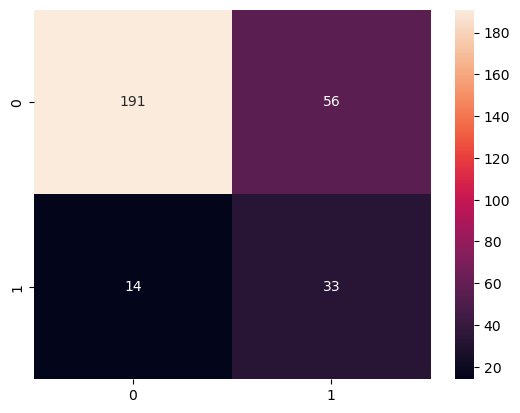

In [63]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(
y_test,
y_pred
)

sns.heatmap(
cm,
annot=True,
fmt="d"
)

plt.show()

# OBSERVATIONS : 
This step creates a Confusion Matrix, which helps evaluate how well the model predicted employee attrition.
Accuracy alone gives one number, but confusion matrix shows correct and incorrect predictions in detail.

Confusion Matrix was used to evaluate the performance of the Logistic Regression model by comparing actual and predicted attrition values. 
It provides detailed insight into correct and incorrect classifications beyond overall accuracy.   

# Classification Report

In [64]:
from sklearn.metrics import classification_report

print(
classification_report(
y_test,
y_pred
)
)

              precision    recall  f1-score   support

          No       0.93      0.77      0.85       247
         Yes       0.37      0.70      0.49        47

    accuracy                           0.76       294
   macro avg       0.65      0.74      0.67       294
weighted avg       0.84      0.76      0.79       294



# OBSERVATIONS:
The classification report indicates that the model performs reasonably well overall, with strong performance for predicting employee retention and moderate capability for identifying employee attrition. The model prioritizes recall for the minority class (Attrition = Yes), which is useful for HR retention analysis.

# Try Random Forest 

Usually better:compared to logistic regression

In [65]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100
)

rf.fit(X_train, y_train)      # ← ye missing tha

pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("RF Accuracy:", accuracy_score(y_test, pred))

from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

RF Accuracy: 0.8537414965986394
              precision    recall  f1-score   support

          No       0.86      0.99      0.92       247
         Yes       0.75      0.13      0.22        47

    accuracy                           0.85       294
   macro avg       0.80      0.56      0.57       294
weighted avg       0.84      0.85      0.81       294



# OBSERVATIONS :
Random Forest performed strongly for predicting employee retention (No) but failed to identify many employees who actually left the company (Yes). 
Therefore, accuracy alone should not determine model selection; recall and F1-score for the minority class should also be considered.

Feature Importance

In [66]:
importance = pd.DataFrame({
'Feature':X.columns,
'Importance':
rf.feature_importances_
})

importance.sort_values(
"Importance",
ascending=False
).head(10)

,Feature,Importance
11,MonthlyIncome,0.055943
0,Age,0.047569
28,PromotionGap,0.044175
29,RiskScore,0.041359
19,TotalWorkingYears,0.040558
1,DailyRate,0.039244
5,EmployeeNumber,0.037018
25,YearsWithCurrManager,0.035381
12,MonthlyRate,0.033887
2,DistanceFromHome,0.033413


# OBSERVATIONS:
This step is called Feature Importance Analysis.
Random Forest automatically calculates which features contribute most to predictions.

Random Forest feature importance analysis identified MonthlyIncome, Age, PromotionGap, and RiskScore as major contributors to employee attrition prediction. The results suggest that compensation, experience, satisfaction, and career progression significantly influence employee retention.

In [67]:
importance = pd.DataFrame({
'Feature':X.columns,
'Importance':
rf.feature_importances_
})

importance.sort_values(
"Importance",
ascending=False
).head(10)

,Feature,Importance
11,MonthlyIncome,0.055943
0,Age,0.047569
28,PromotionGap,0.044175
29,RiskScore,0.041359
19,TotalWorkingYears,0.040558
1,DailyRate,0.039244
5,EmployeeNumber,0.037018
25,YearsWithCurrManager,0.035381
12,MonthlyRate,0.033887
2,DistanceFromHome,0.033413


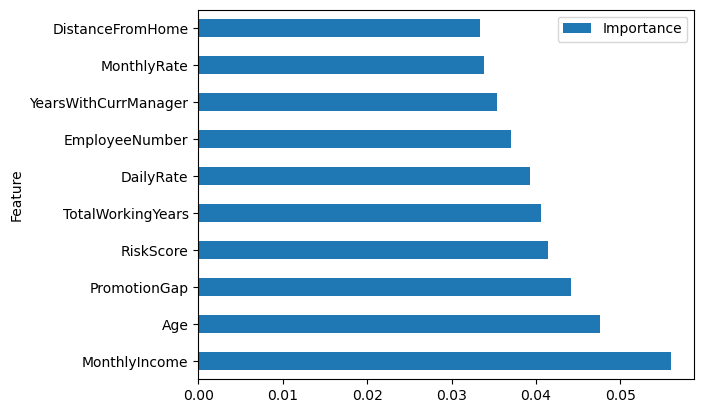

In [68]:
importance.sort_values(

"Importance",

ascending=False

).head(10).plot(

kind="barh",

x="Feature",

y="Importance"

)

plt.show()

#  ROC Curve



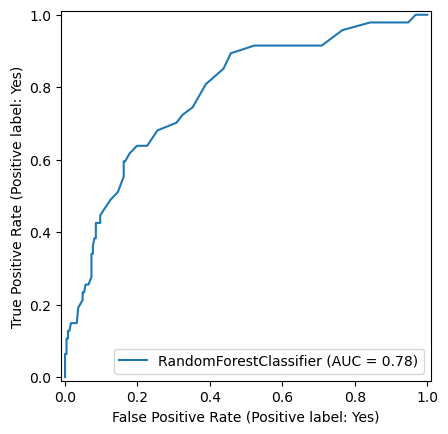

In [69]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
rf,
X_test,
y_test
)

plt.show()

# OBSERVATIONS: 
This step creates the ROC Curve (Receiver Operating Characteristic Curve), which evaluates how well the model distinguishes between:
Attrition = Yes
Attrition = No
This is an important classification model evaluation metric.

ROC Curve was plotted to evaluate the classification performance of the Random Forest model across different thresholds.
A curve closer to the top-left corner indicates better separation between employees who stay and employees who leave the organization.    

# SHAP Analysis
SHAP is known as  Shapley Additive Explanations
It is used to explain machine learning models by showing:
Which features contribute most to a prediction.

In [68]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


# observations :
This command installs the SHAP library, which is used for model explainability in machine learning. SHAP helps understand how different features influence model predictions.
It is useful for:
1. Identifying important features
2. Explaining individual predictions
3. Understanding model behavior
4.Improving interpretability
In employee attrition analysis, SHAP can explain how factors such as salary, age, overtime, and satisfaction affect attrition prediction.

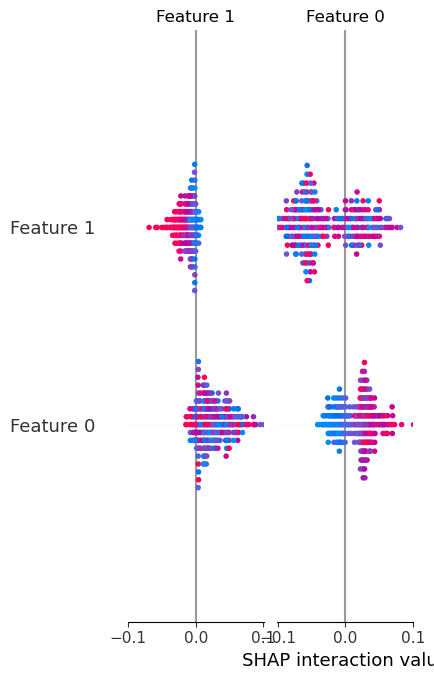

In [70]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
shap_values,
X_test
)

# observations:
This step performs Model Explainability (XAI) using SHAP values for the Random Forest model.
SHAP analysis was used to explain Random Forest predictions by measuring the contribution of each feature toward employee attrition. 
The SHAP summary plot helps identify the most influential factors affecting employee turnover and improves model interpretability.    

# Key Insights from Employee Attrition Analysis
1.Employee Attrition Distribution is Imbalanced
Attrition distribution:
Employees Stayed (No): 1233
Employees Left (Yes): 237
Insight:
The dataset is highly imbalanced, with most employees staying in the company. Therefore, handling imbalance using class_weight='balanced' was important during model training.

2. Overtime has strong impact on Attrition
EDA showed:
Employees working overtime were more likely to leave the company.
Insight:
Higher overtime is associated with increased employee attrition, suggesting workload and work-life balance affect retention.

3. Salary influences Attrition
Insight:
Employees with lower monthly income may have higher probability of leaving the organization.

4. Promotion delays increase Attrition Risk
Insight:
Longer gaps between promotions may increase employee dissatisfaction and attrition.

5. Employee Satisfaction affects Retention
Insight:
Low:
Job Satisfaction
Environment Satisfaction
Relationship Satisfaction
can increase attrition probability.

6. Experience influences Attrition
Insight:
Different experience levels show different attrition behavior.

7. Distance from Home contributes to Attrition
Insight:
Long commute distances may negatively impact employee retention.


# Overall Project Conclusion

The objective of this project was to analyze employee attrition patterns and
build predictive models to identify employees at risk of leaving the company. 
Exploratory data analysis revealed that salary, overtime, promotion delays, satisfaction levels, and
experience significantly influence employee attrition. Machine learning models including Logistic Regression
and Random Forest were trained and evaluated. Logistic Regression performed better in detecting employees likely to leave,
while Random Forest achieved higher overall accuracy. Feature engineering and explainable AI techniques further improved model interpretability. 
The project demonstrates how predictive analytics can support proactive employee retention strategies.

# Business Recommendations
Recommendation 1:
Reduce Overtime Burden
Observation:
Overtime increases attrition risk.
Actions:
1.Improve workload distribution
2.Promote work-life balance
3.Monitor excessive overtime

Recommendation 2:
Improve Compensation Policies
Observation:
MonthlyIncome is top predictor.
Action:
1.Review salary structures
2.Provide competitive compensation
3.Offer performance incentives

Recommendation 3:
Reduce Promotion Delays
Observation:
PromotionGap strongly affects attrition.
Action:
1.Create transparent promotion policies
2.Provide career growth opportunities

Recommendation 4:
Improve Employee Satisfaction
Observation:
Lower satisfaction increases risk.
Action:
1.Employee surveys
2.Feedback programs
3.Manager support initiatives

Recommendation 5:
Identify High-Risk Employees Early
Use predictive models to:
Predict:
Potential attrition risk before resignation occurs.

Recommendation 6:
Focus on Employee Retention Programs
Target:
Employees with:
High RiskScore
Overtime
Low Satisfaction
Low Salary
Long Promotion Gap